# DETR Object Detection: Standard vs 4-Bit Quantization

This notebook compares the same pretrained DETR model in standard precision and with NF4 4-bit weight quantization using `bitsandbytes`.

The original example uses one image. Here we evaluate multiple COCO validation images using the same images, checkpoint, preprocessing, detection protocol, and evaluation data.

The goal is to measure whether 4-bit quantization changes detection quality and inference cost. This is a controlled quantization experiment, not a benchmark of different model architectures.


## Setup

We use the COCO 2017 validation annotations so that the predictions can be evaluated against ground-truth bounding boxes. The same selected images are used for both models.


In [ ]:
!pip install -q transformers bitsandbytes accelerate pycocotools requests Pillow matplotlib pandas

In [ ]:
import os
import json
import time
import requests
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from PIL import Image, ImageDraw
from transformers import AutoModelForObjectDetection, AutoProcessor, BitsAndBytesConfig
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

if not torch.cuda.is_available():
    raise RuntimeError("This notebook requires a CUDA GPU for the 4-bit bitsandbytes experiment.")

torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

model_name = "facebook/detr-resnet-50"
image_dir = "coco_val2017"
ann_file = "instances_val2017.json"

os.makedirs(image_dir, exist_ok=True)

ann_url = "http://images.cocodataset.org/annotations/annotations_trainval2017.zip"
zip_path = "annotations_trainval2017.zip"

if not os.path.exists(ann_file):
    if not os.path.exists(zip_path):
        r = requests.get(ann_url)
        r.raise_for_status()
        open(zip_path, "wb").write(r.content)
    !unzip -o -q annotations_trainval2017.zip "annotations/instances_val2017.json"
    !mv annotations/instances_val2017.json instances_val2017.json

print("Setup complete.")


## Evaluation Subset

A small controlled subset is enough for this experiment, but it should contain multiple images rather than a single example. We select 20 COCO validation images deterministically.

The subset is used unchanged for both models. COCO ground-truth annotations provide the reference data for quantitative evaluation.


In [ ]:
coco = COCO(ann_file)

image_ids = sorted(coco.getImgIds())[:20]
images = coco.loadImgs(image_ids)

print(f"Evaluation images: {len(images)}")
print("Image IDs:", image_ids)

for img_info in images:
    image_path = os.path.join(image_dir, img_info["file_name"])
    if not os.path.exists(image_path):
        url = f"http://images.cocodataset.org/val2017/{img_info['file_name']}"
        r = requests.get(url)
        r.raise_for_status()
        open(image_path, "wb").write(r.content)

print("Images downloaded.")


In [ ]:
def load_image(img_info):
    image_path = os.path.join(image_dir, img_info["file_name"])
    return Image.open(image_path).convert("RGB")

image = load_image(images[0])

plt.figure(figsize=(10, 7))
plt.imshow(image)
plt.title(f"Example COCO Image — {images[0]['file_name']}")
plt.axis("off")
plt.show()


## Standard DETR

The standard model and the quantized model both start from `facebook/detr-resnet-50`. No different checkpoint or model architecture is introduced.

For timing, GPU synchronization is used so that the measured inference time reflects the actual CUDA execution rather than only asynchronous kernel launch time.


In [ ]:
print("Loading standard DETR model...")
model_base = AutoModelForObjectDetection.from_pretrained(model_name).to(device)
processor = AutoProcessor.from_pretrained(model_name)

print("Standard model loaded.")

In [ ]:
def run_base(image):
    inputs = processor(images=image, return_tensors="pt").to(device)

    if torch.cuda.is_available():
        torch.cuda.synchronize()
    start_time = time.perf_counter()

    with torch.no_grad():
        outputs = model_base(**inputs)

    if torch.cuda.is_available():
        torch.cuda.synchronize()
    inference_time = time.perf_counter() - start_time

    target_sizes = torch.tensor([image.size[::-1]], device=device)
    results = processor.post_process_object_detection(
        outputs, threshold=0.001, target_sizes=target_sizes
    )[0]

    return results, inference_time

base_predictions = []
base_times = []

for i, img_info in enumerate(images):
    image = load_image(img_info)
    results, inference_time = run_base(image)

    base_times.append(inference_time)

    for score, label, box in zip(results["scores"], results["labels"], results["boxes"]):
        base_predictions.append({
            "image_id": img_info["id"],
            "score": float(score.cpu()),
            "label": int(label.cpu()),
            "box": box.cpu().tolist()
        })

    print(f"{i + 1:02d}/{len(images)} | {img_info['file_name']} | {inference_time:.4f}s | detections: {len(results['scores'])}")

print(f"Mean inference time: {np.mean(base_times):.4f}s")
print(f"Median inference time: {np.median(base_times):.4f}s")

## 4-Bit Quantization with BitsAndBytes

The quantized model uses the same `facebook/detr-resnet-50` checkpoint with NF4 4-bit weight quantization.

The compute dtype is `bfloat16`. This is different from saying that every operation in the model is performed in 4-bit; bitsandbytes quantizes the stored weights while computation can use the selected higher-precision dtype.


In [ ]:
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16
)

print("Loading 4-bit quantized DETR model...")
model_quant = AutoModelForObjectDetection.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map="auto"
)

print("4-bit model loaded.")

In [ ]:
def run_quant(image):
    inputs = processor(images=image, return_tensors="pt").to(model_quant.device)

    if torch.cuda.is_available():
        torch.cuda.synchronize()
    start_time = time.perf_counter()

    with torch.no_grad():
        outputs = model_quant(**inputs)

    if torch.cuda.is_available():
        torch.cuda.synchronize()
    inference_time = time.perf_counter() - start_time

    target_sizes = torch.tensor([image.size[::-1]], device=model_quant.device)
    results = processor.post_process_object_detection(
        outputs, threshold=0.001, target_sizes=target_sizes
    )[0]

    return results, inference_time

quant_predictions = []
quant_times = []

for i, img_info in enumerate(images):
    image = load_image(img_info)
    results, inference_time = run_quant(image)

    quant_times.append(inference_time)

    for score, label, box in zip(results["scores"], results["labels"], results["boxes"]):
        quant_predictions.append({
            "image_id": img_info["id"],
            "score": float(score.cpu()),
            "label": int(label.cpu()),
            "box": box.cpu().tolist()
        })

    print(f"{i + 1:02d}/{len(images)} | {img_info['file_name']} | {inference_time:.4f}s | detections: {len(results['scores'])}")

print(f"Mean inference time: {np.mean(quant_times):.4f}s")
print(f"Median inference time: {np.median(quant_times):.4f}s")


## Detection Visualization

The visualization uses the same image and a confidence threshold of 0.5 for both models. The quantitative evaluation below keeps predictions above 0.001 so that COCO evaluation can calculate the full precision-recall curve rather than evaluating only one arbitrary confidence threshold.


In [ ]:
def draw_predictions(image, results, model_config, title, threshold=0.5):
    img_copy = image.copy()
    draw = ImageDraw.Draw(img_copy)

    for score, label, box in zip(results["scores"], results["labels"], results["boxes"]):
        if score.item() < threshold:
            continue

        x, y, x2, y2 = box.tolist()
        draw.rectangle((x, y, x2, y2), outline="red", width=3)

        class_name = model_config.id2label[label.item()]
        text = f"{class_name}: {score.item():.2f}"
        text_bbox = draw.textbbox((x, y), text)
        draw.rectangle(text_bbox, fill="red")
        draw.text((x, y), text, fill="white")

    plt.imshow(img_copy)
    plt.title(title)
    plt.axis("off")

example_image = load_image(images[0])

base_example, _ = run_base(example_image)
quant_example, _ = run_quant(example_image)

plt.figure(figsize=(16, 7))

plt.subplot(1, 2, 1)
draw_predictions(example_image, base_example, model_base.config, "Standard DETR", threshold=0.5)

plt.subplot(1, 2, 2)
draw_predictions(example_image, quant_example, model_quant.config, "4-Bit Quantized DETR", threshold=0.5)

plt.tight_layout()
plt.show()


## COCO Quantitative Evaluation

The COCO annotations provide the reference bounding boxes and category labels.

We use COCO evaluation over the same 20 images for both models. `AP50` measures average precision at IoU=0.50, while `mAP` is the standard COCO AP averaged over IoU thresholds from 0.50 to 0.95.

This is a controlled subset evaluation, not a full COCO benchmark.


In [ ]:
# Map DETR class names to COCO category IDs.

coco_categories = coco.loadCats(coco.getCatIds())
name_to_cat_id = {cat["name"]: cat["id"] for cat in coco_categories}

def predictions_to_coco(predictions, model_config):
    coco_predictions = []

    for pred in predictions:
        label_name = model_config.id2label[pred["label"]]

        if label_name not in name_to_cat_id:
            continue

        x1, y1, x2, y2 = pred["box"]
        coco_predictions.append({
            "image_id": pred["image_id"],
            "category_id": name_to_cat_id[label_name],
            "bbox": [x1, y1, x2 - x1, y2 - y1],
            "score": pred["score"]
        })

    return coco_predictions

base_coco_predictions = predictions_to_coco(base_predictions, model_base.config)
quant_coco_predictions = predictions_to_coco(quant_predictions, model_quant.config)

print(f"Standard predictions used for COCO evaluation: {len(base_coco_predictions)}")
print(f"Quantized predictions used for COCO evaluation: {len(quant_coco_predictions)}")


In [ ]:
def evaluate_coco(predictions):
    if len(predictions) == 0:
        return {
            "mAP": np.nan,
            "AP50": np.nan,
            "AP75": np.nan
        }

    result_file = "coco_predictions.json"
    with open(result_file, "w") as f:
        json.dump(predictions, f)

    coco_dt = coco.loadRes(result_file)
    coco_eval = COCOeval(coco, coco_dt, "bbox")
    coco_eval.params.imgIds = image_ids
    coco_eval.evaluate()
    coco_eval.accumulate()
    coco_eval.summarize()

    return {
        "mAP": float(coco_eval.stats[0]),
        "AP50": float(coco_eval.stats[1]),
        "AP75": float(coco_eval.stats[2])
    }

print("Standard DETR COCO evaluation")
base_metrics = evaluate_coco(base_coco_predictions)

print("\n4-Bit Quantized DETR COCO evaluation")
quant_metrics = evaluate_coco(quant_coco_predictions)

## Inference and Memory Comparison

Inference time is averaged over the same images.

GPU memory is reported only when CUDA is available. Peak allocated memory is measured during the inference loop and should be interpreted as runtime memory usage, not as a complete accounting of every memory allocation made by the operating system or CUDA context.


In [ ]:
base_peak_memory = None
quant_peak_memory = None

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

    for img_info in images:
        image = load_image(img_info)
        run_base(image)

    torch.cuda.synchronize()
    base_peak_memory = torch.cuda.max_memory_allocated() / (1024 ** 3)

    del model_base
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()

    torch.cuda.reset_peak_memory_stats()

    for img_info in images:
        image = load_image(img_info)
        run_quant(image)

    torch.cuda.synchronize()
    quant_peak_memory = torch.cuda.max_memory_allocated() / (1024 ** 3)

    print(f"Standard peak allocated GPU memory: {base_peak_memory:.3f} GB")
    print(f"4-bit peak allocated GPU memory: {quant_peak_memory:.3f} GB")
else:
    print("CUDA memory comparison is unavailable.")


## Final Comparison

The table reports the measurements calculated from the selected COCO images.

A positive speedup means the quantized model was faster. A negative change in AP means the quantized model had lower detection quality on this evaluation subset.


In [ ]:
comparison = pd.DataFrame([
    {
        "Model": "Standard DETR",
        "mAP": base_metrics["mAP"],
        "AP50": base_metrics["AP50"],
        "AP75": base_metrics["AP75"],
        "Mean Time (s)": np.mean(base_times),
        "Median Time (s)": np.median(base_times),
        "Images/sec": 1 / np.mean(base_times),
        "Peak GPU Memory (GB)": base_peak_memory
    },
    {
        "Model": "4-Bit NF4 DETR",
        "mAP": quant_metrics["mAP"],
        "AP50": quant_metrics["AP50"],
        "AP75": quant_metrics["AP75"],
        "Mean Time (s)": np.mean(quant_times),
        "Median Time (s)": np.median(quant_times),
        "Images/sec": 1 / np.mean(quant_times),
        "Peak GPU Memory (GB)": quant_peak_memory
    }
])

display(comparison.round(4))

print(f"mAP change: {quant_metrics['mAP'] - base_metrics['mAP']:+.4f}")
print(f"AP50 change: {quant_metrics['AP50'] - base_metrics['AP50']:+.4f}")
print(f"Mean inference time change: {np.mean(quant_times) - np.mean(base_times):+.4f}s")


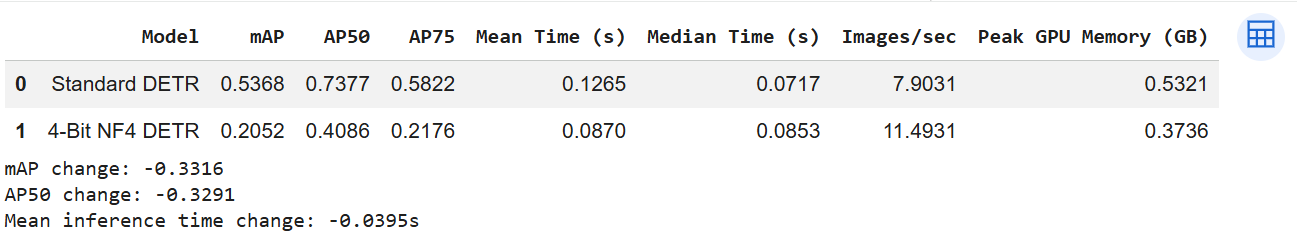

In [ ]:
metrics = ["mAP", "AP50", "AP75"]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(9, 5))
plt.bar(x - width / 2, [base_metrics[m] for m in metrics], width, label="Standard")
plt.bar(x + width / 2, [quant_metrics[m] for m in metrics], width, label="4-Bit NF4")

plt.xticks(x, metrics)
plt.ylabel("Score")
plt.title("Detection Quality Comparison")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(
    ["Standard", "4-Bit NF4"],
    [np.mean(base_times), np.mean(quant_times)]
)

plt.ylabel("Mean inference time (s)")
plt.title("Mean Inference Time")
plt.tight_layout()
plt.show()


# Interpretation and Limitations

The experiment compares standard DETR with NF4 4-bit quantized DETR using the same pretrained model and COCO evaluation subset. The standard model achieved 53.68% mAP and 73.77% AP50, while the 4-bit model achieved 20.52% mAP and 40.86% AP50.

The quantized model was faster, with mean inference time decreasing from 0.1265 s to 0.0870 s, and GPU memory usage decreasing from 0.532 GB to 0.374 GB. However, this efficiency improvement came with a substantial drop in detection accuracy, with mAP decreasing by 0.3316 and AP50 by 0.3291.

Limitations: The evaluation uses only 20 COCO validation images, so the results should not be considered a full COCO benchmark. Also, the 4-bit quantization applies mainly to the transformer linear layers, while the ResNet-50 convolutional backbone remains in full precision. Therefore, the reported memory and performance changes represent partial model quantization, not complete 4-bit quantization.

Overall, the results show that NF4 quantization reduces inference time and GPU memory usage but causes a significant loss in detection quality on this evaluation subset.

## Conclusion

This experiment compares standard and NF4 4-bit versions of the same pretrained DETR model on the same COCO validation subset.

Note that `bitsandbytes` 4-bit quantization only applies to `nn.Linear` layers. In DETR-ResNet-50, this means the transformer encoder/decoder is quantized to NF4, while the ResNet-50 convolutional backbone remains in full precision throughout. The memory and accuracy effects reported below therefore reflect quantizing the transformer component only, not the full model.

The main quantities of interest are detection quality (`mAP`, `AP50`, `AP75`), inference time, and peak GPU memory.

In [ ]:
del processor

if "model_quant" in globals():
    del model_quant

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()

print("Memory cleared.")
